In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from healpy.newvisufunc import projview, newprojplot

from astropy.io import fits
import pandas as pd

from scipy.optimize import curve_fit
import scipy.special as scsp
from scipy.special import gammaln, gammasgn, gamma

import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from scipy.fft import fft, fftfreq
import inspect

from pathlib import Path
from scipy import signal

In [2]:
import mpmath as mp

In [3]:
#-------------------------------------------------------------------------------------------------------------
#Mean Square Displacement Functions
#-------------------------------------------------------------------------------------------------------------

def msd(t, x, max_lag_steps =None, max_lag_seconds=None, cap_at_half_turn=True):
    """
    Compute the mean square displacement mean of (x[i+Δ] - x[i])^2 for a given lag Δ.
    
    Parameters
    ----------
    t : array-like
    Time or in this case, angular scale array
    x : array-like
    Trajectory or fluctuations values
    max_lag_steps  : int or None
    Set number of datapoints
    max_lag_seconds : int or None
    Set maximum lag scale
    cap_at_half_turn : bool
    True avoids double counting 
    and limits calculation to half of the total time or scale

    Returns
    ----------
    t_lag : ndarray
    lag time values
    result : ndarray
    empirical mean square displacement values
    std : ndarray
    standard deviation of MSD at a lag time

    """

    x = np.asarray(x)
    t = np.asarray(t)
    N = len(x)

    result = np.zeros_like(x, dtype=float)
    std = np.zeros_like(x, dtype=float)

    # Decide max lag in points
    if max_lag_steps is None:
        if max_lag_seconds is None:
            max_lag_steps = N - 1
        else:
            lag_step = np.median(np.diff(t))  # if t is uniform angle grid, this is d(angle)
            max_lag_steps  = int(np.floor(max_lag_seconds / lag_step))

    max_lag_steps  = int(np.clip(max_lag_steps , 1, N - 1))

    # For a circle, lags beyond N//2 are the "long way around" (often redundant)
    if cap_at_half_turn:
        max_lag_steps  = min(max_lag_steps , N // 2)

    # Wrapped (circular) MSD
    for i in range(1, max_lag_steps + 1):
        x_shift = np.roll(x, -i)

        # Only use pairs where both points exist
        valid = ~np.isnan(x) & ~np.isnan(x_shift)
        n = np.sum(valid)
    
        if n > 0:
            dx = x_shift[valid] - x[valid]
            sq_dx = dx**2
    
            result[i] = np.mean(sq_dx)
            std[i] = np.std(sq_dx, ddof=1) / np.sqrt(n) if n > 1 else np.nan
        else:
            result[i] = np.nan
            std[i] = np.nan
        
        # dx = np.roll(x, -i) - x      # x[(j+i) mod N] - x[j]
        # sq_dx = dx**2
        # result[i] = np.average(sq_dx)
        # std[i] = np.std(sq_dx, ddof=1) / np.sqrt(len(sq_dx))  # len(sq_dx)=N

    # Lag coordinate: use original "lag unit" idea, but make it match max_lag_steps 
    # If t is uniform grid, lag ≈ i * median(diff(t))
    lag_step = np.median(np.diff(t))
    t_lag = lag_step * np.arange(1, max_lag_steps  + 1)

    return t_lag, result[1:max_lag_steps +1], std[1:max_lag_steps +1]

#-------------------------------------------------------------------------------------------------------------
#Gaussian functions for fitting
# gaussian(. . .) --- fitting based on definition
# gaussian_msd(. . .) --- fitting based sigma = MSD
#-------------------------------------------------------------------------------------------------------------

    
def gaussian(x, mu, sigma):
    return (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-(x - mu)**2 / (2 * sigma**2))

def gaussian_msd(dx, sigma):
    'sigma is msd'
    return (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-dx**2 / (2 * sigma**2))

In [4]:
#-------------------------------------------------------------------------------------------------------------
#mpmath for other functions
#-------------------------------------------------------------------------------------------------------------
def _mp_vectorize_scalar(func, x):
    """
    Evaluate an mpmath scalar function over a NumPy array.

    The result is converted to a NumPy array. If the imaginary part is only
    numerical roundoff, np.real_if_close converts the result back to real.
    """
    x = np.asarray(x)
    vec = np.vectorize(lambda xx: complex(func(float(xx))), otypes=[complex])
    return np.real_if_close(vec(x), tol=1000)


def _whittaker_w(kappa, m, z):
    """Vectorized Whittaker W_{kappa,m}(z) using mpmath."""
    return _mp_vectorize_scalar(lambda zz: mp.whitw(kappa, m, zz), z)


def _hyp3f2(a1, a2, a3, b1, b2, z):
    """Vectorized generalized hypergeometric 3F2 using mpmath."""
    return _mp_vectorize_scalar(
        lambda zz: mp.hyper([a1, a2, a3], [b1, b2], zz), z
    )


def _lower_incomplete_gamma(s, z):
    """Vectorized lower incomplete gamma gamma(s,z) using mpmath."""
    return _mp_vectorize_scalar(lambda zz: mp.gammainc(s, 0, zz), z)


## Model 1

$$
f(t-t')
=
\frac{(t-t')^{H-\frac12}}
{\Gamma\!\left(H+\frac12\right)},
\qquad
h(t')=1.
$$

$$
\boxed{
M_X(t)
=
\frac{t^{2H}}
{2H\,\Gamma^2\!\left(H+\frac12\right)}
}
$$


In [9]:

def msd_01(t, A, H):
    """
    Model 1 MSD.

    Parameters
    ----------
    t : array-like
        Time, lag, or angular-scale array.
    A : float
        Overall normalization.
    H : float
        Hurst-like memory parameter.

    Returns
    -------
    ndarray
        Theoretical MSD values.
    """
    t = np.asarray(t, dtype=float)
    return A * t**(2.0 * H) / (
        2.0 * H * scsp.gamma(H + 0.5)**2
    )


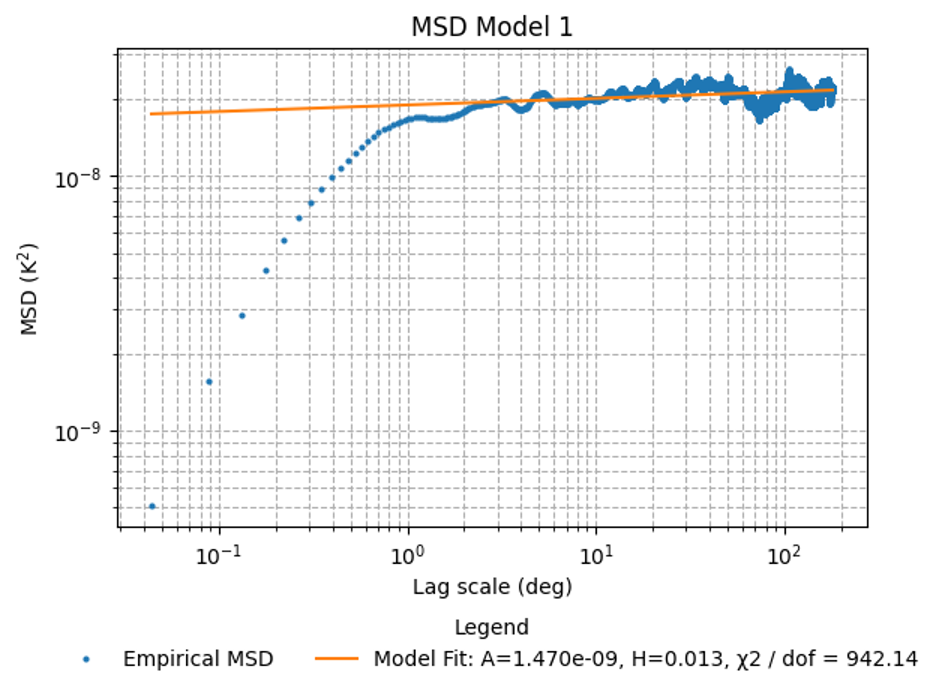


## Model 2

$$
f(t-t')
=
\sqrt{bc}\,
\exp\!\left[-\frac{b}{2}(t-t')\right],
\qquad
h(t')=1.
$$

$$
\boxed{
M_X(t)
=
c\left[1-e^{-bt}\right]
}
$$


In [11]:

def msd_02(t, A, b, c):
    """
    Model 2 MSD.

    Parameters
    ----------
    t : array-like
        Time, lag, or angular-scale array.
    A : float
        Overall normalization.
    b : float
        Exponential decay parameter.
    c : float
        Saturation/amplitude parameter appearing in the table.

    Returns
    -------
    ndarray
        Theoretical MSD values.

    Notes
    -----
    A and c are multiplicatively degenerate if both are fitted freely.
    Set A=1 when c itself is to be interpreted as the fitted amplitude.
    """
    t = np.asarray(t, dtype=float)
    return A * c * (1.0 - np.exp(-b * t))


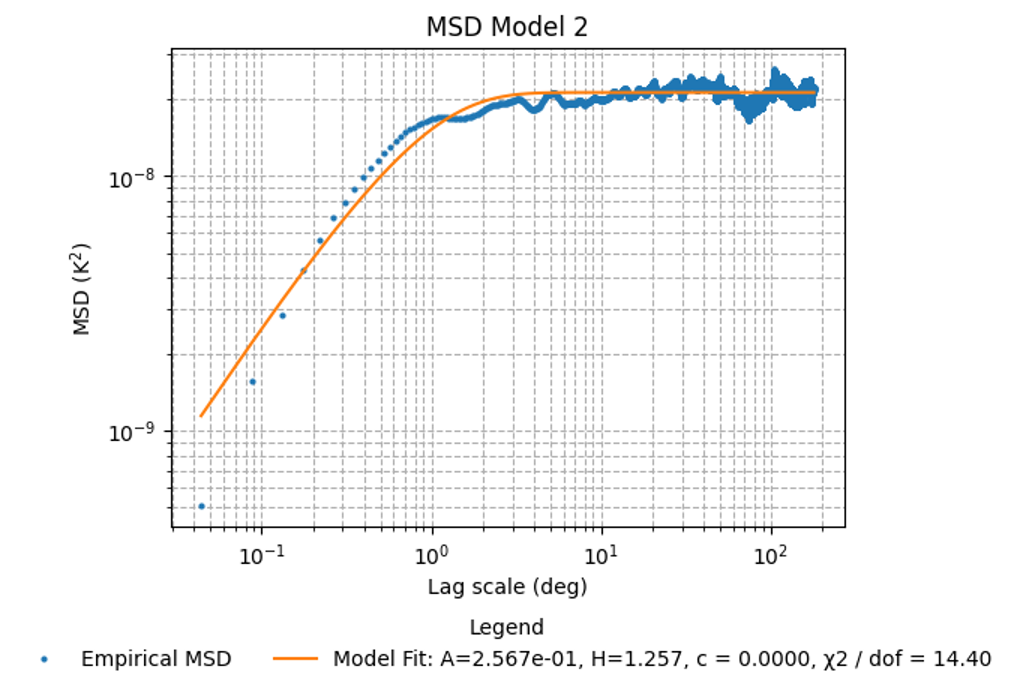


## Model 3

$$
f(t-t')=\sin^{1/2}(t-t'),
\qquad
h(t')=\sqrt{J_0(t')}.
$$

$$
\boxed{M_X(t)=t\,J_1(t)}
$$

Integral-table reference in the supplied table: Eq. (6.674.7).


In [13]:

def msd_03(t, A):
    """Model 3 MSD: A * t * J_1(t)."""
    t = np.asarray(t, dtype=float)
    return A * t * scsp.jv(1, t)


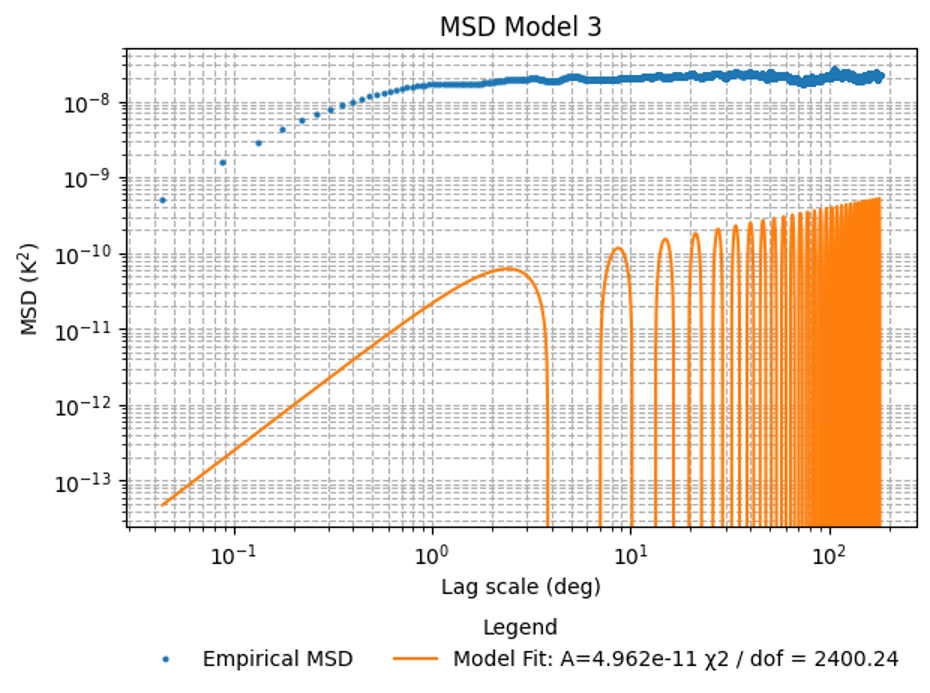


## Model 4

$$
f(t-t')=\cos^{1/2}(t-t'),
\qquad
h(t')=\sqrt{J_0(t')}.
$$

$$
\boxed{M_X(t)=t\,J_0(t)}
$$

Integral-table reference in the supplied table: Eq. (6.674.8).


In [15]:

def msd_04(t, A):
    """Model 4 MSD: A * t * J_0(t)."""
    t = np.asarray(t, dtype=float)
    return A * t * scsp.jv(0, t)


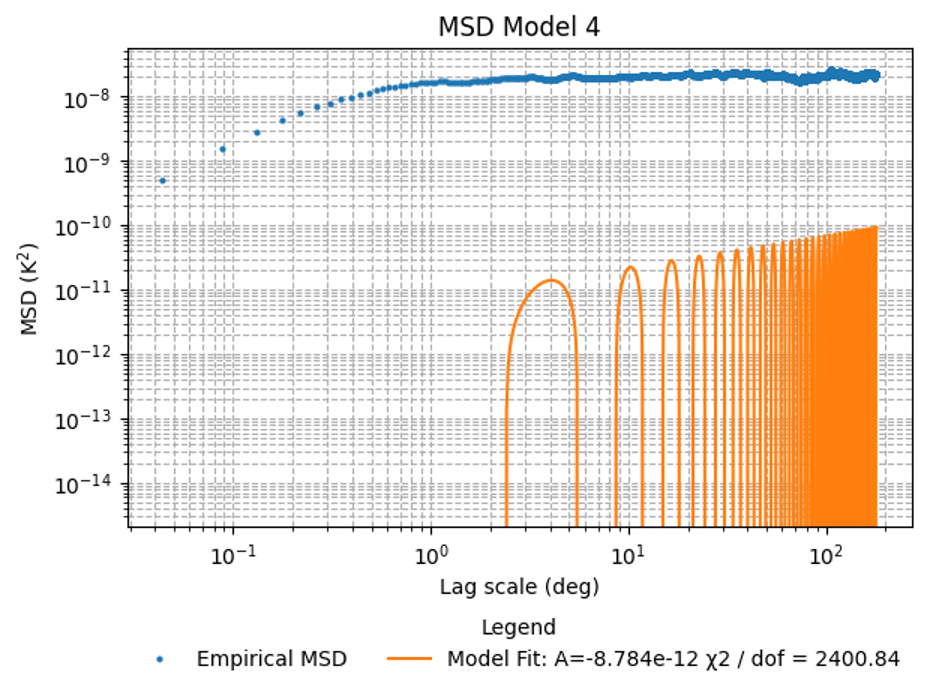


## Model 5

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,\quad t>0,
$$

$$
h(t')
=
\frac{e^{-\beta/(2t')}}
{t'^{(\mu+1)/2}}.
$$

$$
\boxed{
M_X(t)
=
\Gamma(\mu)\,
t^{\mu-1}\beta^{-\mu}e^{-\beta/t}
}
$$

Integral-table reference in the supplied table: Eq. (3.471.3).


In [17]:

def msd_05(t, A, mu, beta):
    """
    Model 5 MSD.

    Parameters
    ----------
    t : array-like
        Time, lag, or angular-scale array. Use t > 0.
    A : float
        Overall normalization.
    mu : float
        Memory parameter.
    beta : float
        Damping parameter.

    Returns
    -------
    ndarray
        Theoretical MSD values.
    """
    t = np.asarray(t, dtype=float)
    return (
        A
        * scsp.gamma(mu)
        * t**(mu - 1.0)
        * beta**(-mu)
        * np.exp(-beta / t)
    )


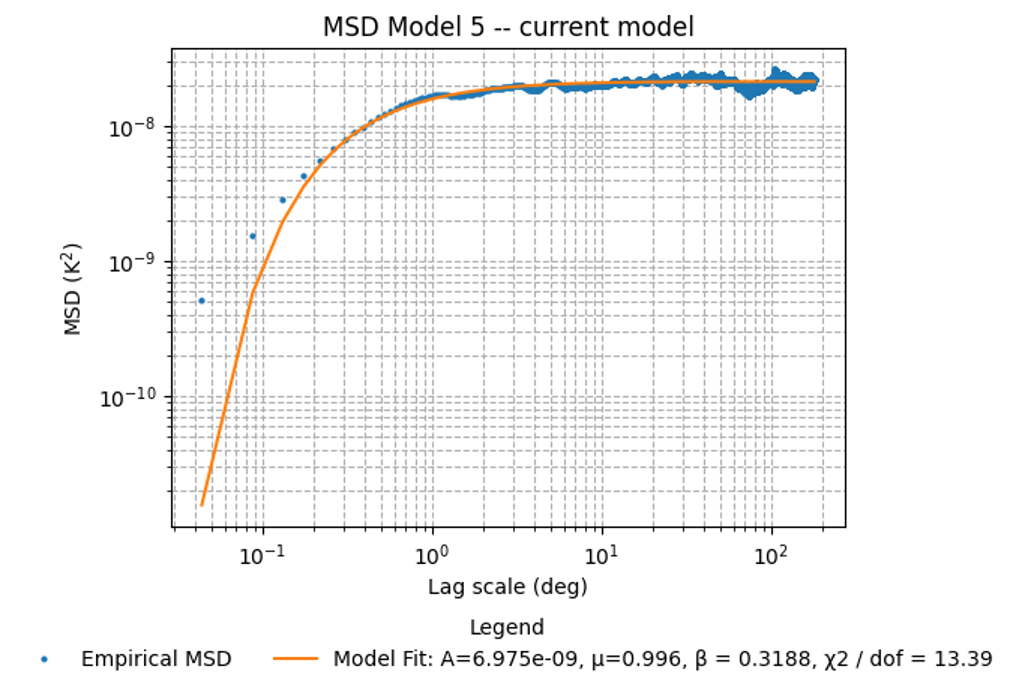


## Model 6

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,\quad t>0,
$$

$$
h(t')
=
\frac{e^{-\beta/(2t')}}
{t'^{(1-\nu)/2}},
\qquad
\operatorname{Re}\beta>0.
$$

$$
\boxed{
M_X(t)
=
\frac{
\Gamma(\mu)
W_{\frac{1-2\mu-\nu}{2},\,\frac{\nu}{2}}
\!\left(\frac{\beta}{t}\right)
}{
\beta^{\frac{1-\nu}{2}}
t^{\frac{1-2\mu-\nu}{2}}
e^{\beta/(2t)}
}
}
$$

Here $W_{\kappa,m}(z)$ is the Whittaker $W$ function.

Integral-table reference in the supplied table: Eq. (3.471.2).


In [21]:

def msd_06(t, A, mu, nu, beta):
    """
    Model 6 MSD involving the Whittaker W function.

    Parameters
    ----------
    t : array-like
        Time, lag, or angular-scale array. Use t > 0.
    A : float
        Overall normalization.
    mu, nu, beta : float
        Parameters appearing in the analytical expression.

    Returns
    -------
    ndarray
        Theoretical MSD values.
    """
    t = np.asarray(t, dtype=float)
    kappa = (1.0 - 2.0 * mu - nu) / 2.0
    m = nu / 2.0
    z = beta / t
    W = _whittaker_w(kappa, m, z)

    denom = (
        beta**((1.0 - nu) / 2.0)
        * t**((1.0 - 2.0 * mu - nu) / 2.0)
        * np.exp(beta / (2.0 * t))
    )
    return A * scsp.gamma(mu) * W / denom



## Model 7

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,\quad t>0,
$$

$$
h(t')
=
\frac{e^{-\beta/(2t')}}{t'^\mu},
\qquad
\operatorname{Re}\beta>0.
$$

$$
\boxed{
M_X(t)
=
\frac{
\Gamma(\mu)e^{-\beta/(2t)}
K_{\mu-\frac12}\!\left(\frac{\beta}{2t}\right)
}{
\sqrt{\pi t}\,
\beta^{\mu-\frac12}
}
}
$$

Here $K_\alpha(z)$ is the modified Bessel function of the second kind.

Integral-table reference in the supplied table: Eq. (3.471.4).


In [23]:

def msd_07(t, A, mu, beta):
    """Model 7 MSD involving K_{mu-1/2}(beta/(2t))."""
    t = np.asarray(t, dtype=float)
    z = beta / (2.0 * t)

    return (
        A
        * scsp.gamma(mu)
        * np.exp(-beta / (2.0 * t))
        * scsp.kv(mu - 0.5, z)
        / (np.sqrt(np.pi * t) * beta**(mu - 0.5))
    )


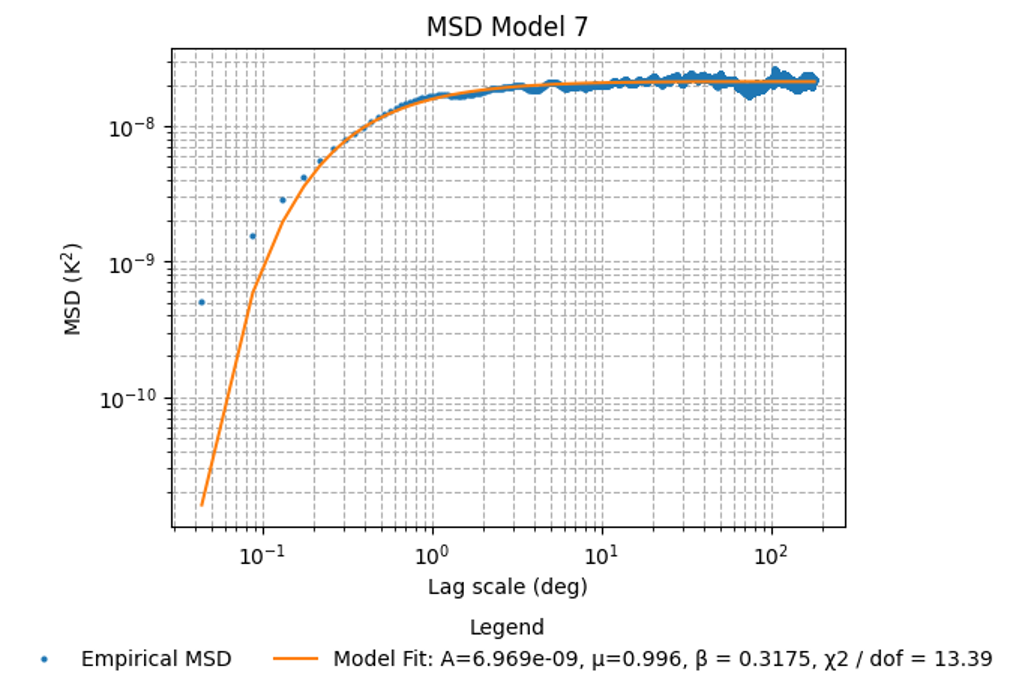


## Model 8

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,
$$

$$
h(t')
=
\frac{e^{\beta t'/2}}
{t'^{(1-\nu)/2}},
\qquad
\operatorname{Re}\nu>0.
$$

$$
\boxed{
M_X(t)
=
\frac{
2B(\mu,\nu)\,
{}_1F_1(\nu;\mu+\nu;\beta t)
}{
t^{\,1-\mu-\nu}
}
}
$$

Here $B$ is the beta function and ${}_1F_1$ is the confluent hypergeometric function.

Integral-table reference in the supplied table: Eq. (3.383.1).


In [25]:

def msd_08(t, A, mu, nu, beta):
    """Model 8 MSD involving the confluent hypergeometric 1F1."""
    t = np.asarray(t, dtype=float)
    return (
        A
        * 2.0
        * scsp.beta(mu, nu)
        * scsp.hyp1f1(nu, mu + nu, beta * t)
        / t**(1.0 - mu - nu)
    )


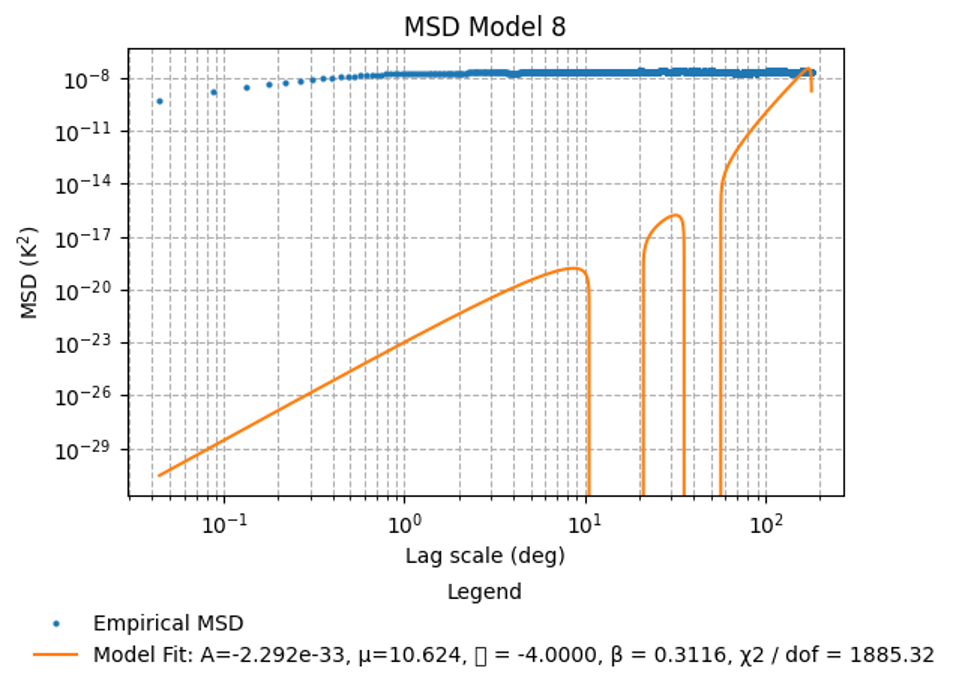


## Model 9

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,
$$

$$
h(t')
=
\frac{e^{\beta t'/2}}
{t'^{(1-\mu)/2}}.
$$

$$
\boxed{
M_X(t)
=
\frac{
\sqrt{\pi}\,\Gamma(\mu)\,
I_{\mu-\frac12}\!\left(\frac{\beta t}{2}\right)
}{
e^{-\beta t/2}
\left(\frac{t}{\beta}\right)^{\frac12-\mu}
}
}
$$

Integral-table reference in the supplied table: Eq. (3.383.2).


In [28]:

def msd_09(t, A, mu, beta):
    """Model 9 MSD involving I_{mu-1/2}(beta*t/2)."""
    t = np.asarray(t, dtype=float)
    z = beta * t / 2.0

    denom = (
        np.exp(-beta * t / 2.0)
        * (t / beta)**(0.5 - mu)
    )
    return (
        A
        * np.sqrt(np.pi)
        * scsp.gamma(mu)
        * scsp.iv(mu - 0.5, z)
        / denom
    )


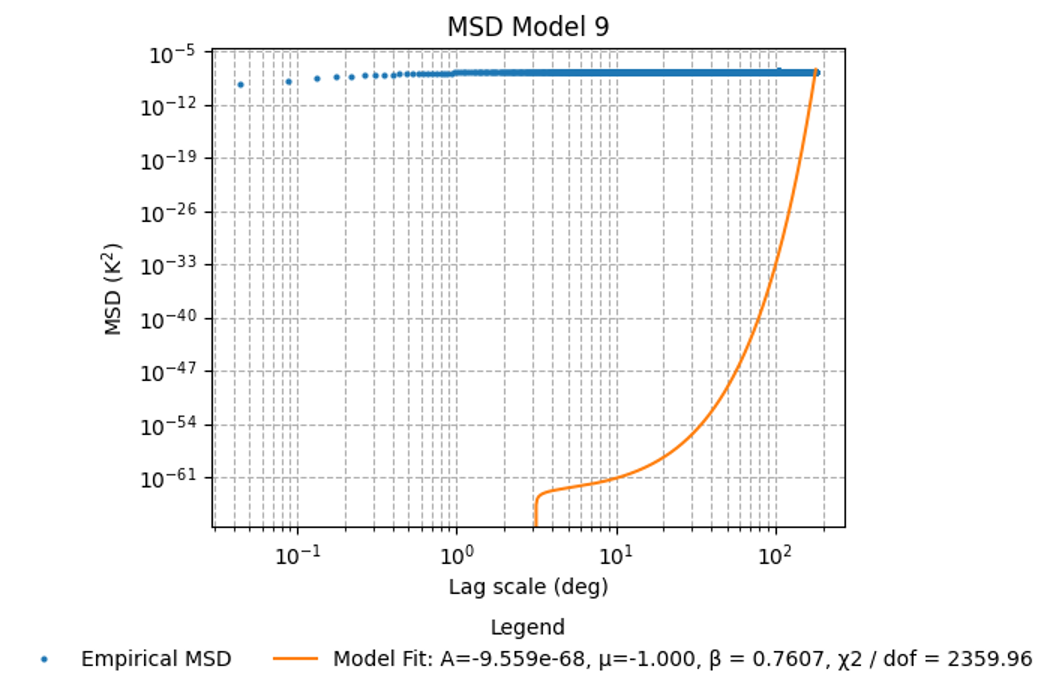


## Model 10

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,
$$

$$
h(t')
=
\frac{e^{-\beta t'/2}}
{t'^{(1-\mu)/2}}.
$$

$$
\boxed{
M_X(t)
=
\frac{
\sqrt{\pi}\,\Gamma(\mu)\,
I_{\mu-\frac12}\!\left(\frac{\beta t}{2}\right)
}{
e^{\beta t/2}
\left(\frac{t}{\beta}\right)^{\frac12-\mu}
}
}
$$

Integral-table reference in the supplied table: Eq. (3.388.1).


In [30]:

def msd_10(t, A, mu, beta):
    """Model 10 MSD involving I_{mu-1/2}(beta*t/2)."""
    t = np.asarray(t, dtype=float)
    z = beta * t / 2.0

    denom = (
        np.exp(beta * t / 2.0)
        * (t / beta)**(0.5 - mu)
    )
    return (
        A
        * np.sqrt(np.pi)
        * scsp.gamma(mu)
        * scsp.iv(mu - 0.5, z)
        / denom
    )


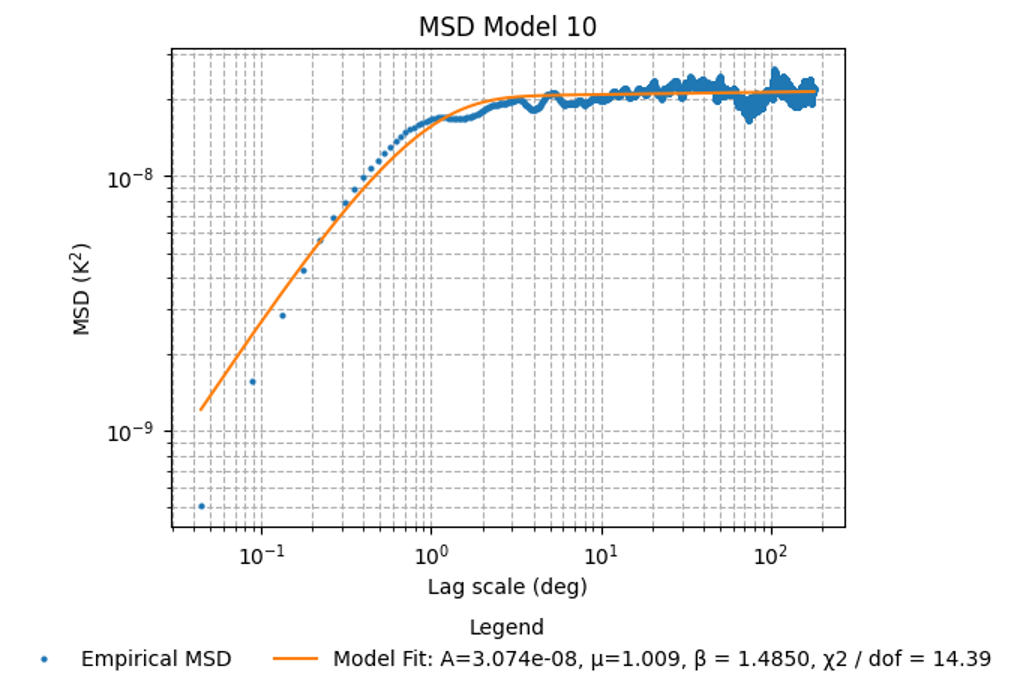


## Model 11

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,
$$

$$
h(t')
=
\frac{\sin^{1/2}(at')}
{t'^{(1-\mu)/2}}.
$$

$$
\boxed{
M_X(t)
=
\frac{
\Gamma(\mu)\sin(at/2)
J_{\mu-\frac12}(at/2)
}{
\pi^{-1/2}
t^{\frac12-\mu}
a^{\mu-\frac12}
}
}
$$

Integral-table reference in the supplied table: Eq. (3.768.7).


In [32]:

def msd_11(t, A, mu, a):
    """Model 11 MSD involving J_{mu-1/2}(a*t/2)."""
    t = np.asarray(t, dtype=float)
    z = a * t / 2.0

    denom = (
        np.pi**(-0.5)
        * t**(0.5 - mu)
        * a**(mu - 0.5)
    )
    return (
        A
        * scsp.gamma(mu)
        * np.sin(z)
        * scsp.jv(mu - 0.5, z)
        / denom
    )


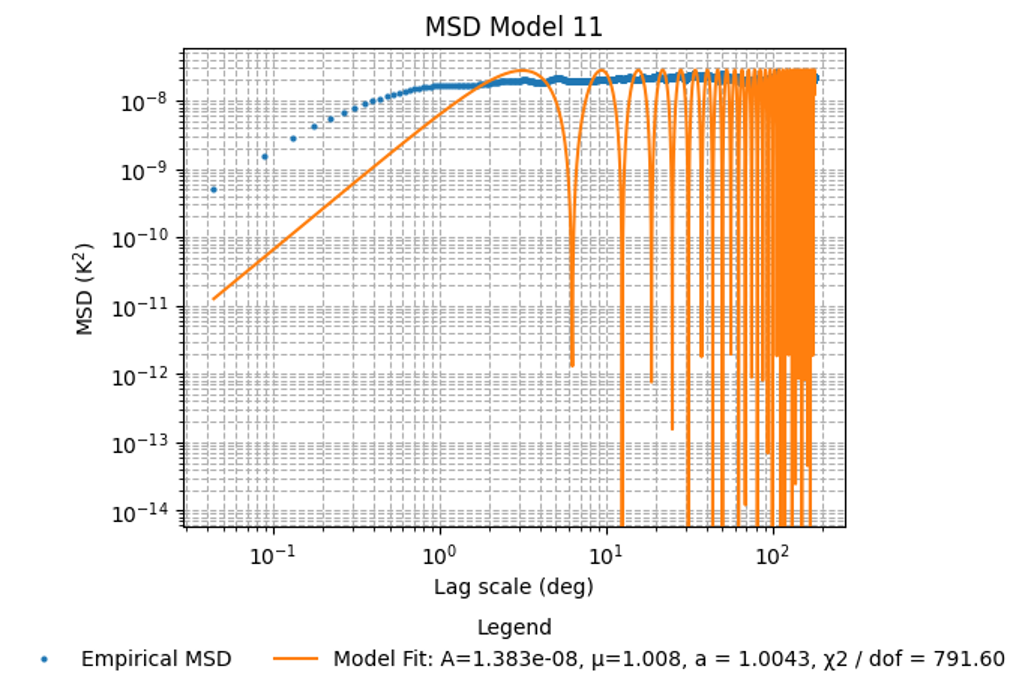


## Model 12

$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,
$$

$$
h(t')
=
\frac{\cos^{1/2}(at')}
{t'^{(1-\mu)/2}}.
$$

$$
\boxed{
M_X(t)
=
\frac{
\Gamma(\mu)\cos(at/2)
J_{\mu-\frac12}(at/2)
}{
\pi^{-1/2}
t^{\frac12-\mu}
a^{\mu-\frac12}
}
}
$$

Integral-table reference in the supplied table: Eq. (3.768.9).


In [34]:

def msd_12(t, A, mu, a):
    """Model 12 MSD involving J_{mu-1/2}(a*t/2)."""
    t = np.asarray(t, dtype=float)
    z = a * t / 2.0

    denom = (
        np.pi**(-0.5)
        * t**(0.5 - mu)
        * a**(mu - 0.5)
    )
    return (
        A
        * scsp.gamma(mu)
        * np.cos(z)
        * scsp.jv(mu - 0.5, z)
        / denom
    )


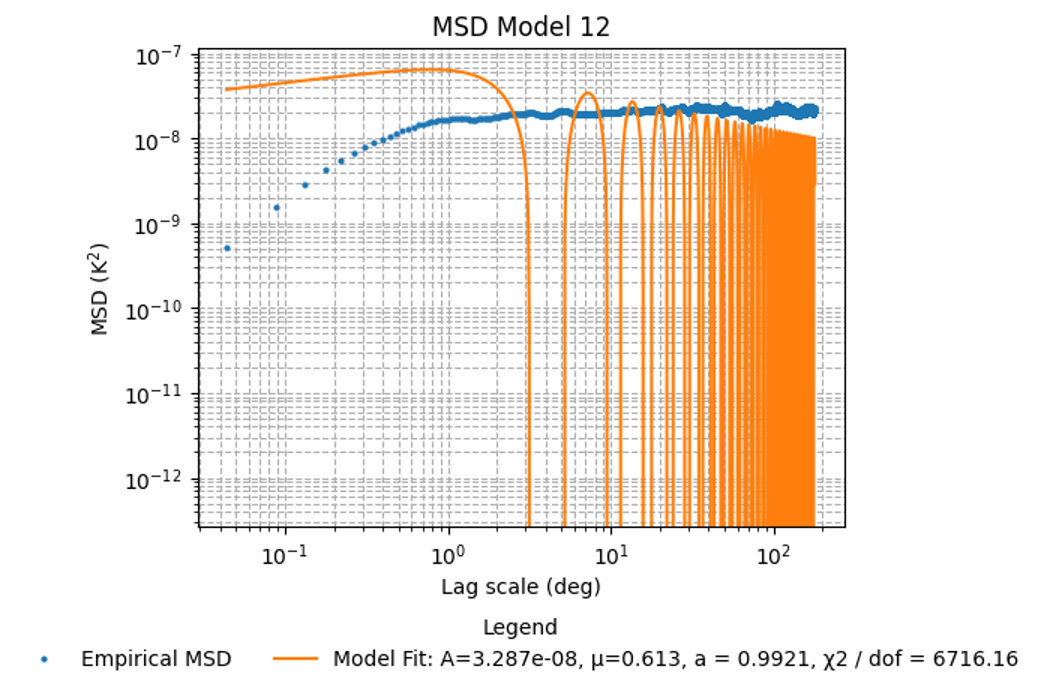

> **Correction used for Model 13:** the MSD is implemented with the numerator and denominator interchanged relative to the initial image transcription, and with the power $t^{\,1-\lambda-\mu}$ in the denominator. Equivalently,
> $$
 M_X(t)=
 \beta^{2\nu}B(\lambda,\mu)t^{\lambda+\mu-1}
 {}_3F_2\!\left(
 -\nu,\frac{\lambda}{2},\frac{\lambda+1}{2};
 \frac{\lambda+\mu}{2},\frac{\lambda+\mu+1}{2};
 -\frac{t^2}{\beta^2}
 \right).
 $$


## Model 13 — corrected


$$
f(t-t')=(t-t')^{\frac{\mu-1}{2}},
\qquad
\operatorname{Re}\mu>0,
$$

$$
h(t')
=
\frac{(t'^2+\beta^2)^{\nu/2}}
{t'^{(1-\lambda)/2}},
\qquad
\lambda>0.
$$

The corrected MSD is

$$
\boxed{
M_X(t)
=
\frac{
\beta^{2\nu}B(\lambda,\mu)\,
{}_3F_2\!\left(
-\nu,\frac{\lambda}{2},\frac{\lambda+1}{2};
\frac{\lambda+\mu}{2},\frac{\lambda+\mu+1}{2};
-\frac{t^2}{\beta^2}
\right)
}{
t^{\,1-\lambda-\mu}
}
}
$$

or equivalently,

$$
\boxed{
M_X(t)
=
\beta^{2\nu}B(\lambda,\mu)t^{\lambda+\mu-1}\,
{}_3F_2\!\left(
-\nu,\frac{\lambda}{2},\frac{\lambda+1}{2};
\frac{\lambda+\mu}{2},\frac{\lambda+\mu+1}{2};
-\frac{t^2}{\beta^2}
\right)
}
$$

with $\operatorname{Re}(t/\beta)>0$.

Integral-table reference in the supplied table: Eq. (3.254.1).


In [36]:

def msd_13(t, A, mu, nu, lam, beta):
    """
    Corrected Model 13 MSD.

    Parameters
    ----------
    t : array-like
        Time, lag, or angular-scale array.
    A : float
        Overall normalization.
    mu : float
        Memory parameter.
    nu : float
        Power parameter of (t'^2 + beta^2).
    lam : float
        Lambda parameter; use lam > 0.
    beta : float
        Scale parameter.

    Returns
    -------
    ndarray
        Theoretical MSD values.

    Notes
    -----
    This implements

        beta^(2 nu) * B(lam, mu) * t^(lam + mu - 1)
        * 3F2(-nu, lam/2, (lam+1)/2;
              (lam+mu)/2, (lam+mu+1)/2;
              -t^2/beta^2).

    mpmath is used for 3F2.
    """
    t = np.asarray(t, dtype=float)
    z = -(t / beta)**2

    hyp = _hyp3f2(
        -nu,
        lam / 2.0,
        (lam + 1.0) / 2.0,
        (lam + mu) / 2.0,
        (lam + mu + 1.0) / 2.0,
        z,
    )

    result = (
        A
        * beta**(2.0 * nu)
        * scsp.beta(lam, mu)
        * t**(lam + mu - 1.0)
        * hyp
    )
    return np.real_if_close(result, tol=1000)


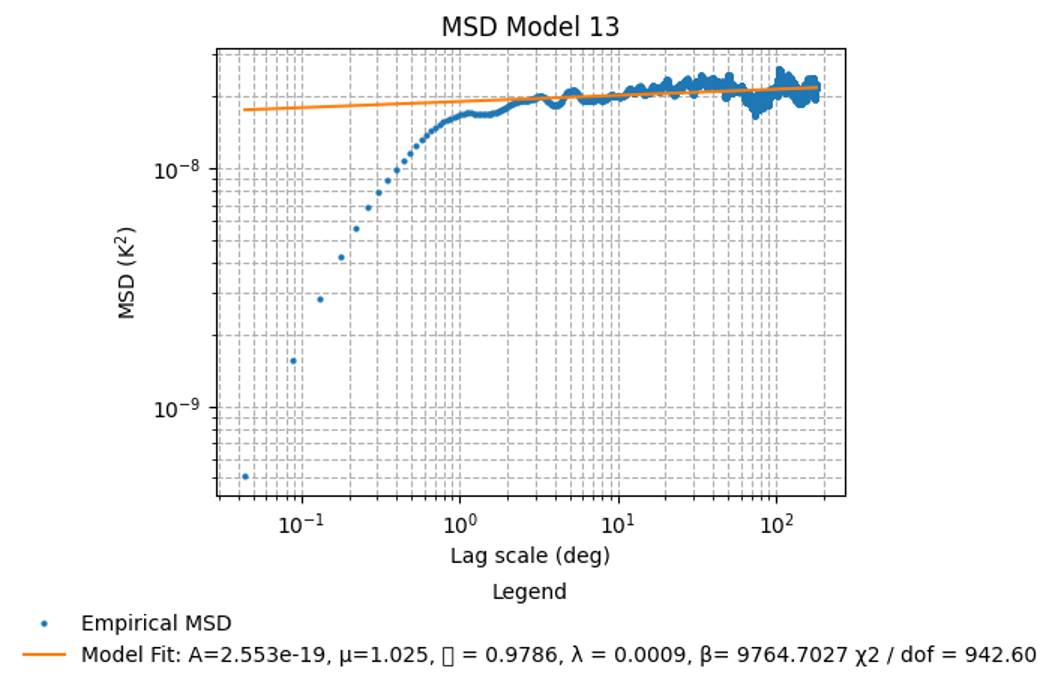


## Model 14

$$
f(t-t')=(t-t')^{-\nu/2},
\qquad
|\operatorname{Re}\nu|<1,
$$

$$
h(t')
=
\sqrt{\frac{t'^\nu}{t'-c}},
\qquad
c<t'.
$$

$$
\boxed{
M_X(t)
=
\frac{
\pi\left[
1-\cos(\nu\pi)
\left(\frac{c}{t-c}\right)^\nu
\right]
}{
\csc^{-1}(\nu\pi)
}
}
$$

Integral-table reference in the supplied table: Eq. (3.228.1).

**Coding note:** here $\csc^{-1}x$ is treated as the reciprocal of $\csc x$, i.e. $\csc^{-1}x=\sin x$. Thus the denominator in the code is $\sin(\nu\pi)$.


In [38]:

def msd_14(t, A, nu, c):
    """Model 14 MSD, with csc^{-1}(x) interpreted as 1/csc(x)=sin(x)."""
    t = np.asarray(t, dtype=float)

    numerator = np.pi * (
        1.0
        - np.cos(nu * np.pi)
        * (c / (t - c))**nu
    )
    denominator = np.sin(nu * np.pi)

    return A * numerator / denominator


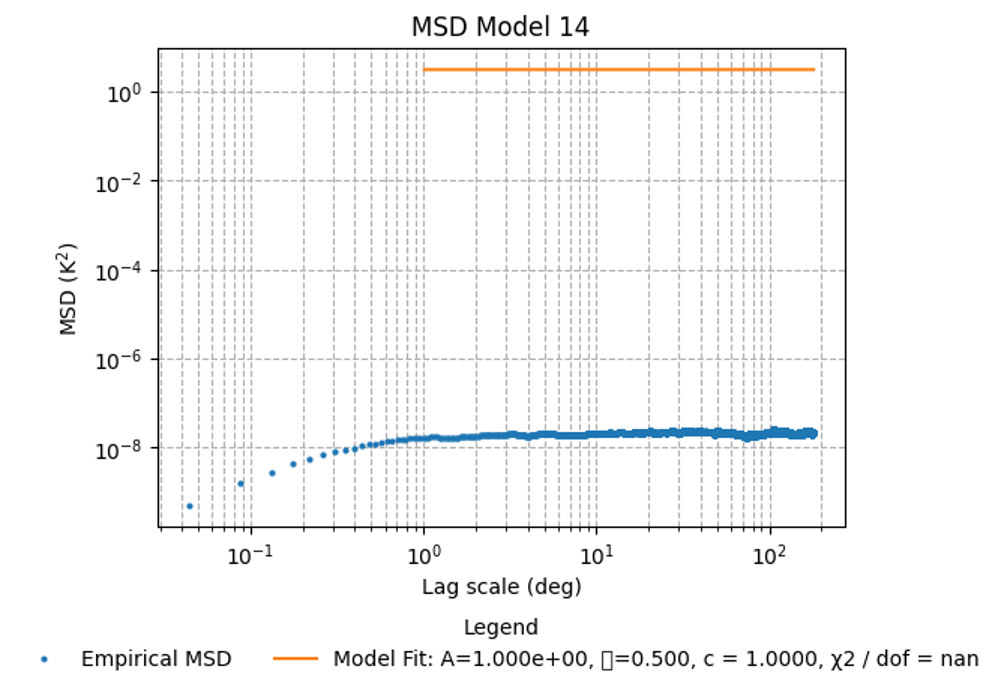


## Model 15

$$
f(t-t')=(t-t')^{-\nu/2},
\qquad
0.5<\operatorname{Re}\nu<1,
$$

$$
h(t')
=
\sqrt{\frac{t'^{\nu-1}}{t'-c}},
\qquad
c<t'.
$$

$$
\boxed{
M_X(t)
=
\frac{
-\pi c^{\nu-1}\cot(\nu\pi)
}{
(t-c)^\nu
}
}
$$

Integral-table reference in the supplied table: Eq. (3.228.2).


In [40]:

def msd_15(t, A, nu, c):
    """Model 15 MSD."""
    t = np.asarray(t, dtype=float)
    cot = 1.0 / np.tan(nu * np.pi)

    return (
        A
        * (-np.pi)
        * c**(nu - 1.0)
        * cot
        / (t - c)**nu
    )


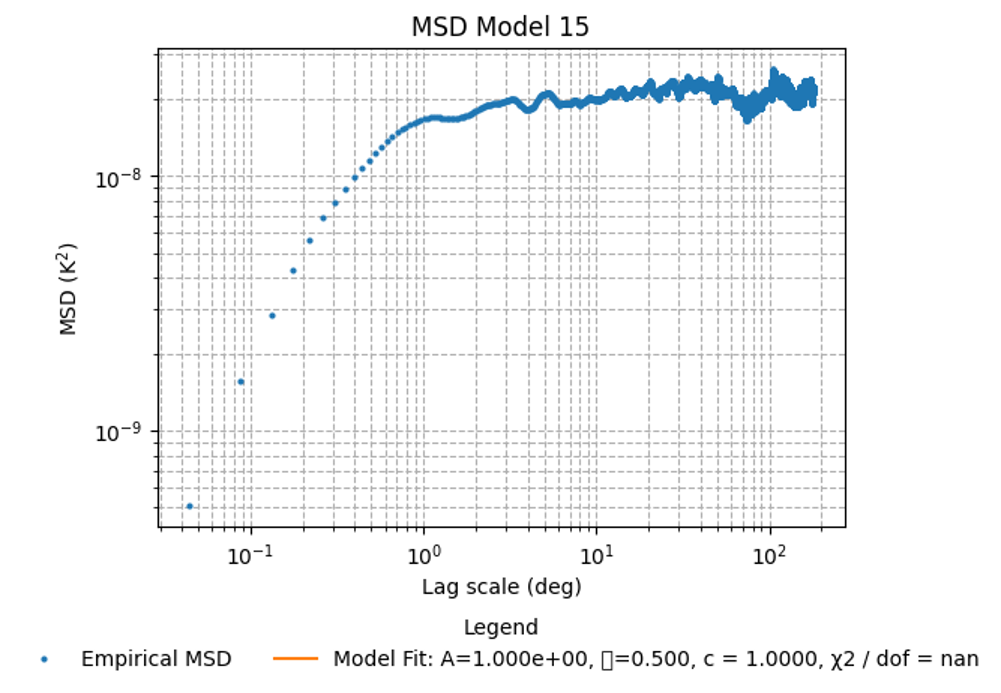

The model did not fit the empirical MSD


## Model 16

$$
f(t-t')=(t-t')^{\nu/2},
\qquad
\operatorname{Re}\nu>-1,\quad t>0,
$$

$$
h(t')=e^{-\mu t'/2}.
$$

$$
\boxed{
M_X(t)
=
\frac{
(-\mu)^{-\nu-1}
\gamma(\nu+1,-t\mu)
}{
e^{t\mu}
}
}
$$

Here $\gamma(s,z)$ is the lower incomplete gamma function.

Integral-table reference in the supplied table: Eq. (3.382.1).


In [20]:

def msd_16(t, A, nu, mu):
    """
    Model 16 MSD involving the lower incomplete gamma function.

    mpmath is used because the gamma-function argument -mu*t may be negative,
    in which case SciPy's regularized real-valued gammainc is not sufficient.
    """
    t = np.asarray(t, dtype=float)

    gamma_lower = _lower_incomplete_gamma(nu + 1.0, -mu * t)
    prefactor = complex(-mu) ** (-nu - 1.0)

    result = (
        A
        * prefactor
        * gamma_lower
        / np.exp(mu * t)
    )
    return np.real_if_close(result, tol=1000)


RecursionError: maximum recursion depth exceeded

Possibly did not converge!


## Model 17

$$
f(t-t')=
\sqrt{J_{1-\nu}(t-t')},
\qquad
-1<\operatorname{Re}\nu<2,
$$

$$
h(t')=\sqrt{J_\nu(t')}.
$$

$$
\boxed{
M_X(t)=J_0(t)-\cos t
}
$$

Integral-table reference in the supplied table: Eq. (11.3.38).


In [42]:

def msd_17(t, A):
    """Model 17 MSD."""
    t = np.asarray(t, dtype=float)
    return A * (scsp.jv(0, t) - np.cos(t))


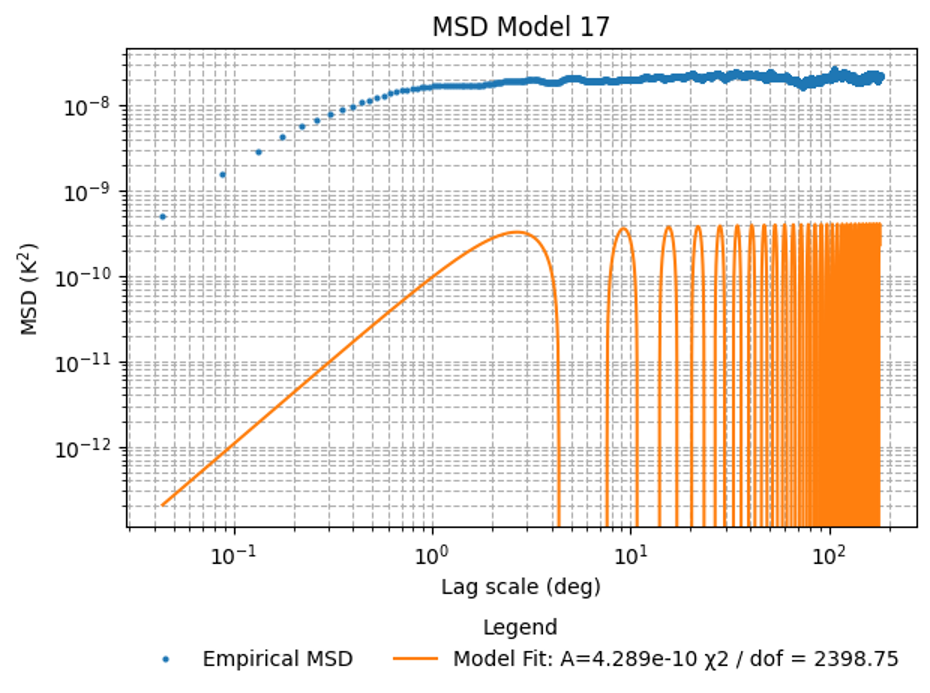


## Model 18

$$
f(t-t')=
\sqrt{J_\nu(t-t')},
\qquad
\operatorname{Re}\nu>-1,
$$

$$
h(t')
=
\sqrt{t'^{-1}J_\mu(t')},
\qquad
\operatorname{Re}\mu>0.
$$

$$
\boxed{
M_X(t)=\frac{J_{\mu+\nu}(t)}{\mu}
}
$$

Integral-table reference in the supplied table: Eq. (11.3.40).


In [44]:

def msd_18(t, A, mu, nu):
    """Model 18 MSD."""
    t = np.asarray(t, dtype=float)
    return A * scsp.jv(mu + nu, t) / mu


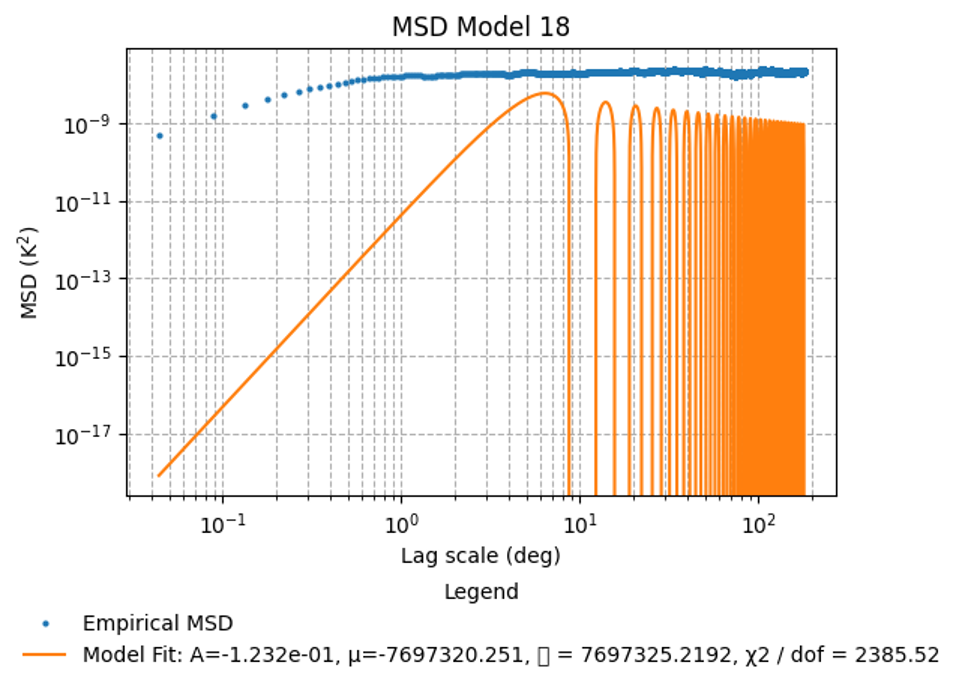